# Machine Learning Coursework: Question 3 - Optimization using Genetic Algorithms and MIP

### Setup 

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from IPython.display import Image, display

sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('src'))

# DI stuff
from di.container import AppContainer
container = AppContainer()
# usecase 
data_prep_usecase = container.data_preparation_usecase()
ga_solver_usecase = container.genetic_algorithm_usecase()
mip_solver_usecase = container.mip_solver_usecase()
compare_and_report_usecase = container.compare_and_report_usecase()

## 1. Data Preparation

- 30 IT projects
- Has resource (budget and Developer hrs) constraints
- Has Logical Constrainst (mutual exclusion and interdependant) project

Data is kept at Q3/data directory

In [2]:
instance = data_prep_usecase.execute(num_projects=30, seed=42)

df_proj = pd.DataFrame([
    {"ID": p.id, "Profit ($k)": p.profit, "Cost ($k)": p.cost, "Dev Hours (hours)": p.dev_hours}
    for p in instance.projects
])
display(df_proj.head(10))
print(f"Mutual Exclusion Projects: {instance.mutual_exclusions}")
print(f"Dependeny Projects: {instance.dependencies}")

2026-07-28 14:40:24,484 | INFO     | [ML_CW_Q3] Loaded 30 projects. Total Cost: 2,226.4k, Total Dev Hours: 2,566.5h
2026-07-28 14:40:24,485 | INFO     | [ML_CW_Q3] Organization Capacity: Budget: 1,113.2k, Dev Hours limit: 1,283.3h


,ID,Profit ($k),Cost ($k),Dev Hours (hours)
0,0,161.2,65.6,147.2
1,1,230.0,143.3,53.5
2,2,184.2,113.8,40.3
3,3,194.5,95.8,88.5
4,4,163.0,36.1,158.0
5,5,113.1,36.1,53.9
6,6,108.9,22.8,114.1
7,7,248.6,131.9,126.6
8,8,181.8,96.2,53.3
9,9,215.5,110.6,122.0


Mutual Exclusion Projects: [(3, 7), (12, 18), (22, 27)]
Dependeny Projects: [(8, 2), (15, 10), (25, 20)]


### Project Distribution Plot
Visualize the cost vs profit of 30 projects. The size of the points represents the required developer dev hours.

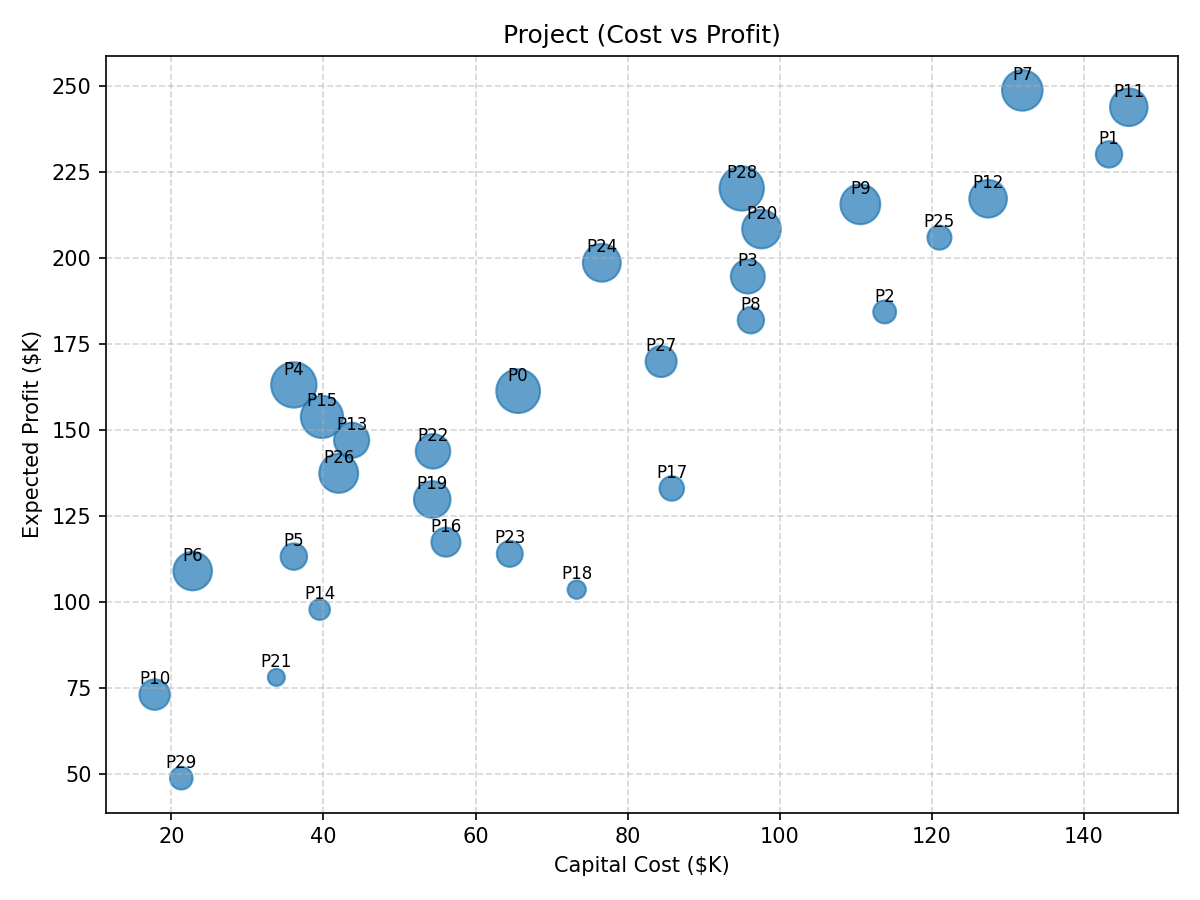

In [8]:
display(Image("plots/project_distribution.png"))

## 2. GA Optimization

Run GA and first tune hyperparameters over different population sizes and generation sizes to find best para mvalues.

In [9]:
# Hyperparameter tuning
tuning_results = ga_solver_usecase.hyperParamTune(instance, pop_sizes=[50, 100, 200, 300], gens=[50, 100, 150, 200])
best_params = tuning_results["best_params"]
print(f"Best Hyperparameters found: {best_params}")

2026-07-28 14:43:01,089 | INFO     | [ML_CW_Q3] GA: pop_size=50, generations=50, mutation_rate=0.0333...
2026-07-28 14:43:01,164 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2427.3k, Feasible: True
2026-07-28 14:43:01,164 | INFO     | [ML_CW_Q3] GA: pop_size=50, generations=100, mutation_rate=0.0333...
2026-07-28 14:43:01,287 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2424.4k, Feasible: True
2026-07-28 14:43:01,287 | INFO     | [ML_CW_Q3] GA: pop_size=50, generations=150, mutation_rate=0.0333...
2026-07-28 14:43:01,467 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2446.0k, Feasible: True
2026-07-28 14:43:01,468 | INFO     | [ML_CW_Q3] GA: pop_size=50, generations=200, mutation_rate=0.0333...
2026-07-28 14:43:01,702 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2460.8k, Feasible: True
2026-07-28 14:43:01,703 | INFO     | [ML_CW_Q3] GA: pop_size=100, generations=50, mutation_rate=0.0333...
2026-07-28 14:43:01,825 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2468.

###  GA Optimization
Run GA with best params (pop size =  100, generations = 150)

In [10]:
ga_solution, history_best = ga_solver_usecase.findBestProjects(
    instance, 
    pop_size=100, 
    generations=150
)

print(f"Profit: ${ga_solution.total_profit:,.1f}k")
print(f"Resource Usage: Cost: ${ga_solution.total_cost:,.1f}k / ${instance.budget:,.1f}k, Dev Hours: {ga_solution.total_labor:,.1f}h / {instance.dev_hours_limit:,.1f}h")
print(f"Solution : {ga_solution.is_feasible}")

2026-07-28 14:43:10,851 | INFO     | [ML_CW_Q3] GA: pop_size=100, generations=150, mutation_rate=0.0333...
2026-07-28 14:43:11,206 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2509.5k, Feasible: True
Profit: $2,509.5k
Resource Usage: Cost: $1,087.5k / $1,113.2k, Dev Hours: 1,283.8h / 1,283.3h
Solution : True


### GA Best Fitnee and Project Selection Visualization

FileNotFoundError: No such file or directory: 'plots/ga_best_fit.png'

FileNotFoundError: No such file or directory: 'plots/ga_best_fit.png'

<IPython.core.display.Image object>

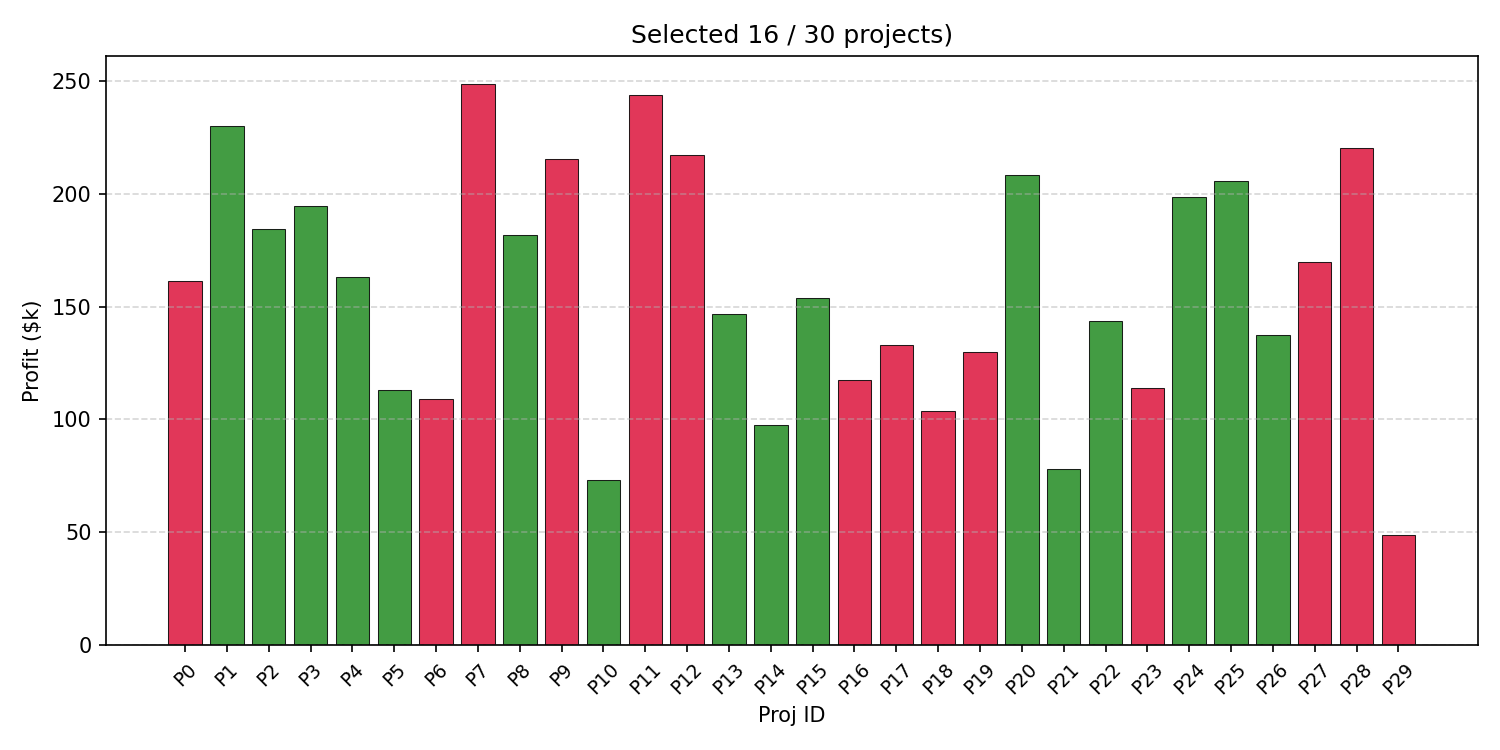

In [11]:
ga_solver_usecase.plot_results(instance, ga_solution, history_best)
display(Image("plots/ga_best_fit.png"))
display(Image("plots/ga_portfolio_selection.png"))

- The best individual is preserved — Best fitness never dropped
- Each 'step' up - discovering a better solution
- Flat - exploring but has not yet found an improvement



## 3. Mixed Integer Programming


In [6]:
mip_solution, mip_time = mip_solver_usecase.find_best_projects(instance)
print(f"Optimal Profit: ${mip_solution.total_profit:.1f}k")
print(f"Cost: ${mip_solution.total_cost:.1f}k from ${instance.budget:.1f}k")
print(f"Dev Hours: {mip_solution.total_labor:.1f}h from {instance.dev_hours_limit:.1f}h")
print(f"Exec Time: {mip_time:.4f} seconds")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/287a237ceb334d2cae172f36911503f0-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/287a237ceb334d2cae172f36911503f0-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 13 COLUMNS
At line 176 RHS
At line 185 BOUNDS
At line 216 ENDATA
Problem MODEL has 8 rows, 30 columns and 72 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 2542.07 - 0.00 seconds
Cgl0004I processed model has 8 rows, 30 columns (30 integer (30 of which binary)) and 72 elements
Cutoff increment increased from 1e-05 to 0.0999
Cbc0038I Initial state - 3 integers unsatisfied sum - 0.9930

### Selection Visualizatrion

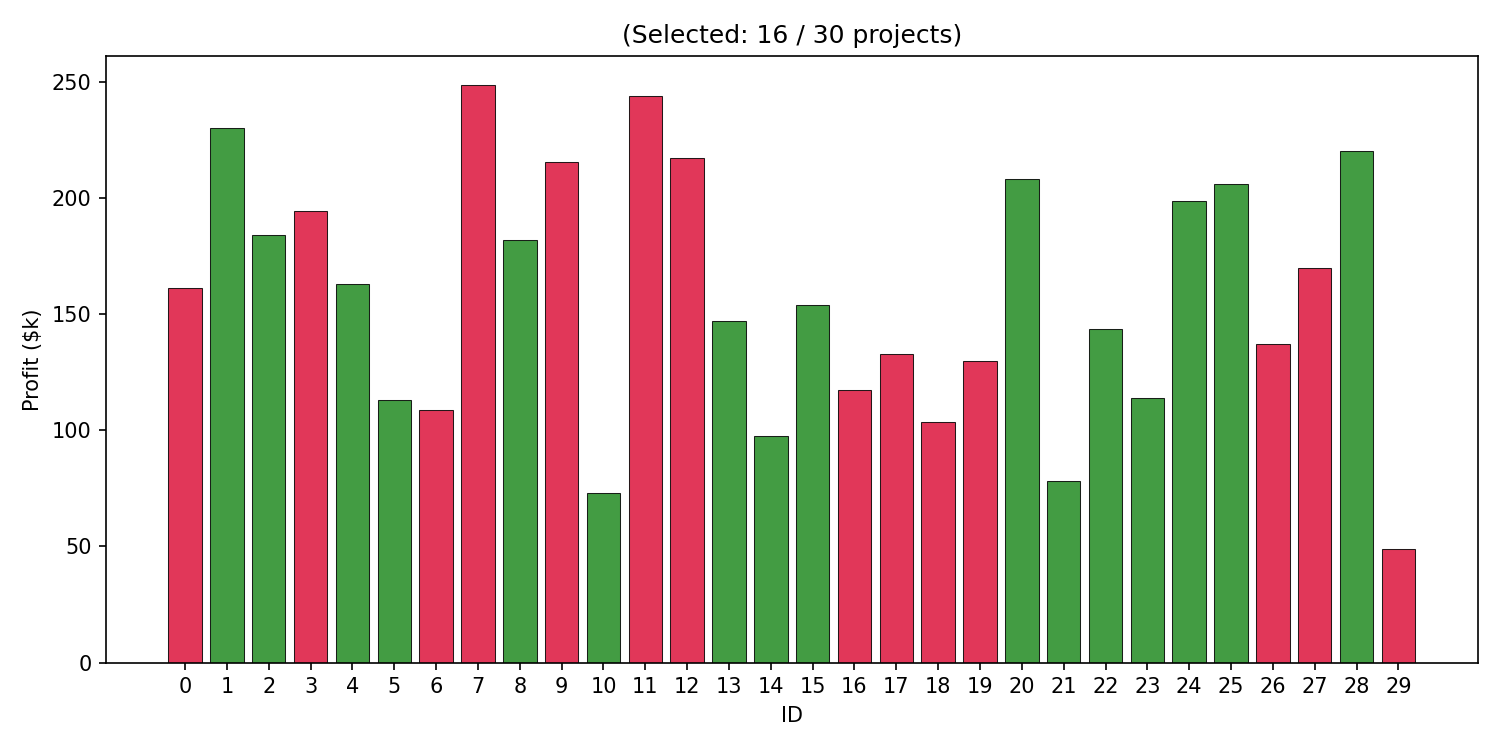

In [7]:
mip_solver_usecase.plot_results(instance, mip_solution)
display(Image("plots/mip_portfolio_selection.png"))